# Building and electric-bus use-case analysis

This notebook is the reproducible analysis layer for the annual building cases. It compares the diesel benchmark, unidirectional charging, least-cost V2G, grid-support objectives, rooftop PV, renewable-aware operation, and the exploratory export-remuneration cases.

All electric cases use the same 2024 route-distance profiles and 15-minute resolution. Battery degradation and investment costs are outside the boundary. The route figure uses **indicative service corridors**, not measured GPS traces; the depot figure uses the digitised roof polygons.

## Use-case catalogue

| ID | Use case | Direction | Main KPI / status |
| --- | --- | --- | --- |
| D0 | Diesel bus operation reference | Fuel-only | Fuel cost and direct bus CO₂ |
| I01 | Electric bus depot charging reference | V1G | Import cost, peak import, mobility compliance |
| I02a | Least-cost V2G at current export payment | V2G, 5 kW export limit | Import cost minus export revenue; expected zero export at 2.20 THB/kWh |
| I02b | Least-cost V2G at economically viable export payment | V2G, 5 kW export limit | Export onset, export energy, and cost change near the break-even tariff |
| I03 | Maximum grid support without export | V2G/V1G, no export | Reduction in import during grid-stress intervals |
| I04a | Maximum grid support with 5 kW policy export limit | V2G, 5 kW export limit | Grid relief plus regulated grid injection |
| I04b | Maximum grid support with 450 kW technical export sensitivity | V2G, 450 kW export limit | Grid relief plus technical grid-injection sensitivity |
| I05 | Maximum renewable-deficit support without export | V2G, no export | Renewable-equivalent deficit support using the availability proxy |
| I06a | Maximum renewable-deficit support with 5 kW policy export limit | V2G, 5 kW export limit | Renewable-equivalent support and regulated export sensitivity |
| I06b | Maximum renewable-deficit support with 450 kW technical export sensitivity | V2G, 450 kW export limit | Renewable-equivalent support and technical export sensitivity |
| I07 | Depot PV self-consumption | PV + buses | PV used for bus charging and curtailment |
| I08 | Emergency backup | V2G reserve | Critical-load backup hours; not yet implemented |
| I09 | Stationary-battery substitution | V2G | Avoided battery capacity and utilisation; not yet implemented |
| I10 | Exploratory export-remuneration sweep | V2G | Export volume and break-even remuneration |
| I11 | Renewable-aware operation using renewable-equivalent proxy | V1G/V2G | Renewable-equivalent shifting; not a direct carbon dispatch |
| I12 | Depot building-load support | V2B | Currently out of scope because non-traction load is zero |
| I13 | Peer-to-peer electricity trading | V2G | Trading revenue; not yet implemented |

The current study boundary contains bus traction charging, bus V2X operation, grid import/export, and rooftop PV. It excludes non-traction depot demand, battery degradation cost, vehicle investment, and peer-to-peer settlement. I02a uses the current 2.20 THB/kWh export payment; I02b represents a targeted higher-remuneration sensitivity, with 3.20 THB/kWh already shown to induce annual export in the completed tariff sweep. I04a and I04b separate the regulated 5 kW export case from the 450 kW technical sensitivity. In I04a/I04b, `max_grid_support` first maximises congestion-weighted technical service, then reduces unnecessary battery throughput and technical import cost; the export payment is not the dispatch-driving objective. I04a represents the current 5 kW-per-meter policy limit, while I04b is a technical sensitivity and must not be interpreted as an approved Thai export capacity. I05/I06 maximise renewable-deficit support using a common renewable-availability proxy; they are technical renewable-alignment cases, not least-cost economic dispatch and not claims of metered renewable electricity absorption.

## 1. Setup, cases, and reproducibility

Set `RUN_MISSING_CORE_CASES = True` to calculate missing core annual outputs. The optional sensitivity sweeps have their own `RUN_SENSITIVITY_CASES` switch and are `False` by default, so a normal notebook run cannot launch them accidentally. Existing outputs are always loaded.

In [29]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError('Could not find the FLEXIMOD project root')


PROJECT_ROOT = find_project_root()
INPUT_ROOT = PROJECT_ROOT / 'data' / 'input'
OUTPUT_ROOT = PROJECT_ROOT / 'data' / 'output' / 'building_use_case_analysis'
SOURCE_ROOT = PROJECT_ROOT / 'docs' / 'sources'
FORECAST_PATH = INPUT_ROOT / 'building_v1g_annual' / 'forecasts_df.csv'
ROOF_PATH = SOURCE_ROOT / 'borom_depot_roof_polygons.geojson'
ROUTE_PATH = SOURCE_ROOT / 'modeled_bus_route_corridors.geojson'

RUN_MISSING_CORE_CASES = False
RUN_SENSITIVITY_CASES = False

# D0 documented 2024 assumptions; see docs/sources/diesel_reference_2024.md.
DIESEL_FUEL_CONSUMPTION_L_PER_KM = 1.0 / 2.55  # BMTA diesel-bus average.
DIESEL_PRICE_THB_PER_L = 31.89  # 2024 national average retail diesel price.
DIESEL_TAILPIPE_CO2_KG_PER_L = 2.5503727392  # B7 fossil Scope 1, including CH4 and N2O.
DIESEL_BIOGENIC_CO2_KG_PER_L = 0.11507832  # B7 biogenic CO2, reported separately.
DIESEL_CARBON_TAX_THB_PER_L = 0.0  # No separate automobile carbon tax in 2024.
GRID_CO2_KG_PER_MWH = 499.9
CREDIT_GRID_EXPORT = False

CORE_CASES = {
    'V1G baseline': {'input': 'building_v1g_annual', 'study_case': 'building_v1g_annual', 'output': 'v1g_baseline'},
    'I02a least-cost V2G at current export payment': {'input': 'building_v2b_cost_annual', 'study_case': 'building_v2b_cost_annual', 'output': 'v2b_cost'},
    'I02b economically viable V2G export': {'input': 'building_v2g_tariff_sweep_annual', 'study_case': 'building_v2g_sweep_plus_1000', 'output': 'tariff_plus_1000'},
    'V2B maximum grid relief': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2b_grid_support_max_no_export', 'output': 'grid_support_no_export'},
    'I04a maximum grid support at 5 kW policy limit': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2g_grid_support_max_export_5kw', 'output': 'grid_support_export_5kw'},
    'I04b maximum grid support at 450 kW technical sensitivity': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2g_grid_support_max_export_450kw', 'output': 'grid_support_export_450kw'},
    'I05 maximum renewable-deficit support without export': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2b_renewable_shifting_max_no_export', 'output': 'renewable_shifting_no_export'},
    'I06a maximum renewable-deficit support at 5 kW policy limit': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2g_renewable_shifting_max_export_5kw', 'output': 'renewable_shifting_export_5kw'},
    'I06b maximum renewable-deficit support at 450 kW technical sensitivity': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2g_renewable_shifting_max_export_450kw', 'output': 'renewable_shifting_export_450kw'},
    'V2B rooftop PV': {'input': 'building_v2b_pv_self_consumption_annual', 'study_case': 'building_v2b_pv_self_consumption', 'output': 'v2b_rooftop_pv'},
    'V2G current export payment': {'input': 'building_v2g_current_tariff_annual', 'study_case': 'building_v2g_current_tariff_annual', 'output': 'v2g_current_export'},
}
GRID_SUPPORT_CASES = {
    'No export': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2b_grid_support_max_no_export', 'output': 'grid_support_no_export', 'export_limit_kw': 0},
    '5 kW policy limit': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2g_grid_support_max_export_5kw', 'output': 'grid_support_export_5kw', 'export_limit_kw': 5},
    '450 kW technical limit': {'input': 'building_v2b_grid_support_annual', 'study_case': 'building_v2g_grid_support_max_export_450kw', 'output': 'grid_support_export_450kw', 'export_limit_kw': 450},
}
RENEWABLE_CASES = {
    'No export': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2b_renewable_shifting_max_no_export', 'output': 'renewable_shifting_no_export', 'export_limit_kw': 0},
    '5 kW policy limit': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2g_renewable_shifting_max_export_5kw', 'output': 'renewable_shifting_export_5kw', 'export_limit_kw': 5},
    '450 kW technical limit': {'input': 'building_v2b_renewable_alignment_annual', 'study_case': 'building_v2g_renewable_shifting_max_export_450kw', 'output': 'renewable_shifting_export_450kw', 'export_limit_kw': 450},
}
TARIFF_CASES = {f'Export +{increment / 1000:.1f} THB/kWh': {'input': 'building_v2g_tariff_sweep_annual', 'study_case': ('building_v2g_sweep_current' if increment == 0 else f'building_v2g_sweep_plus_{increment}'), 'output': f'tariff_plus_{increment}', 'increment_thb_per_kwh': increment / 1000} for increment in range(0, 5001, 500)}

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'blue': '#0072B2', 'orange': '#D55E00', 'green': '#009E73', 'purple': '#7B61A8', 'grey': '#6B7280'}
print(f'Project root: {PROJECT_ROOT}')
print(f'Analysis outputs: {OUTPUT_ROOT}')

Project root: /root/FLEXIMOD
Analysis outputs: /root/FLEXIMOD/data/output/building_use_case_analysis


In [30]:
def output_dir(spec: dict) -> Path:
    return OUTPUT_ROOT / spec['output']


def run_case(label: str, spec: dict, allow_run: bool) -> None:
    destination = output_dir(spec)
    summary_path = destination / 'summary_indicators.csv'
    dispatch_path = destination / 'dispatch_results.csv'
    if summary_path.exists() and dispatch_path.exists():
        return
    if not allow_run:
        print(f'Missing {label}: {destination}')
        return
    destination.mkdir(parents=True, exist_ok=True)
    command = [sys.executable, '-m', 'flexi_mod.simulation.run_case', '--case', str(INPUT_ROOT / spec['input']), '--study-case', spec['study_case'], '--output-dir', str(destination), '--no-plots']
    print(f'Running {label}')
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)


for label, spec in CORE_CASES.items():
    run_case(label, spec, RUN_MISSING_CORE_CASES)

print('Core annual outputs available:', sum((output_dir(spec) / 'summary_indicators.csv').exists() for spec in CORE_CASES.values()), '/', len(CORE_CASES))

Core annual outputs available: 10 / 10


## 2. Diesel benchmark

The diesel benchmark uses the same per-timestep route kilometres, with bus traction supplied by diesel. It is a traction-only benchmark: depot building electricity, demand charges, vehicle capital costs, maintenance, upstream fuel emissions, and battery manufacturing are excluded.

| D0 input | Value | Treatment |
| --- | ---: | --- |
| Diesel consumption | 1 / 2.55 = 0.3922 L/km | BMTA diesel-bus average |
| Diesel price | 31.89 THB/L | 2024 annual average retail price; no further fuel tax added |
| Bus emissions | 2.5504 kgCO2e/L | B7 fossil Scope 1, including CH4 and N2O |
| B7 biogenic CO2 | 0.1151 kgCO2/L | Reported separately; excluded from Scope 1 total |
| Carbon tax | 0 THB/L | No separate automobile carbon tax in 2024 |

Sources and scope are documented in `docs/sources/diesel_reference_2024.md`.

In [31]:
forecast = pd.read_csv(FORECAST_PATH, parse_dates=['datetime']).set_index('datetime')
distance_columns = [column for column in forecast if column.endswith('_trip_distance_km')]
if not distance_columns:
    raise ValueError('No per-bus trip-distance columns were found')
dt_hours = float(forecast.index.to_series().diff().dropna().dt.total_seconds().median() / 3600)
route_totals = forecast[distance_columns].sum().rename(lambda value: value.removesuffix('_trip_distance_km')).rename('annual_distance_km')
display(route_totals.to_frame())

total_distance_km = float(route_totals.sum())
diesel_litre = total_distance_km * DIESEL_FUEL_CONSUMPTION_L_PER_KM
diesel_fuel_cost = diesel_litre * (DIESEL_PRICE_THB_PER_L + DIESEL_CARBON_TAX_THB_PER_L)
diesel_bus_scope1_co2 = diesel_litre * DIESEL_TAILPIPE_CO2_KG_PER_L
diesel_biogenic_co2 = diesel_litre * DIESEL_BIOGENIC_CO2_KG_PER_L
diesel_total_cost = diesel_fuel_cost
diesel_operational_co2 = diesel_bus_scope1_co2

diesel_row = {
    'scenario': 'Diesel benchmark', 'distance_km': total_distance_km, 'fuel_litre': diesel_litre,
    'diesel_fuel_cost_THB': diesel_fuel_cost, 'diesel_carbon_tax_THB': diesel_litre * DIESEL_CARBON_TAX_THB_PER_L,
    'energy_cost_THB': diesel_fuel_cost, 'demand_charge_THB': 0.0, 'total_cost_THB': diesel_total_cost,
    'grid_import_MWh': 0.0, 'grid_export_MWh': 0.0,
    'peak_grid_import_MW': 0.0, 'operational_CO2_kg': float(diesel_operational_co2),
    'diesel_bus_scope1_CO2e_kg': float(diesel_bus_scope1_co2), 'diesel_biogenic_CO2_kg': float(diesel_biogenic_co2),
    'pv_available_MWh': 0.0, 'pv_used_MWh': 0.0, 'pv_curtailment_MWh': 0.0,
    'grid_import_during_stress_MWh': 0.0,
    'renewable_alignment_score': np.nan,
}
display(pd.Series(diesel_row).to_frame('value'))

,annual_distance_km
bus_route_7k,87840.0
bus_route_79,102480.0
bus_route_101,105408.0


,value
scenario,Diesel benchmark
distance_km,295728.0
fuel_litre,115971.764706
diesel_fuel_cost_THB,3698339.576471
diesel_carbon_tax_THB,0.0
energy_cost_THB,3698339.576471
demand_charge_THB,0.0
total_cost_THB,3698339.576471
grid_import_MWh,0.0
grid_export_MWh,0.0


## 3. Load electric results and build a common KPI table

In [32]:
def load_result(label: str, spec: dict) -> tuple[dict, pd.DataFrame] | None:
    summary_path = output_dir(spec) / 'summary_indicators.csv'
    dispatch_path = output_dir(spec) / 'dispatch_results.csv'
    if not summary_path.exists() or not dispatch_path.exists():
        return None
    summary = pd.read_csv(summary_path).iloc[0]
    dispatch = pd.read_csv(dispatch_path, parse_dates=['datetime']).set_index('datetime')
    # Apply one common 2024 renewable-availability signal to every case.
    # Most cases do not need the signal to optimise, but all cases need it for a fair comparison.
    signal_path = INPUT_ROOT / 'building_v2b_renewable_alignment_annual' / 'forecasts_df.csv'
    signal_frame = pd.read_csv(signal_path, usecols=['datetime', 'renewable_availability_weight', 'renewable_rich_threshold'], parse_dates=['datetime']).set_index('datetime')
    renewable_rich_threshold = float(signal_frame['renewable_rich_threshold'].iloc[0])
    signal = signal_frame['renewable_availability_weight']
    signal.index = signal.index.tz_localize(dispatch.index.tz)
    dispatch['renewable_availability_weight'] = signal.reindex(dispatch.index)
    if dispatch['renewable_availability_weight'].isna().any():
        raise ValueError(f'Renewable signal does not cover {label}')
    # This is an availability-weighted charging indicator, not a claim about metered renewable electrons.
    common_renewable_absorbed = float((dispatch['bus_charge_MWh'] * dispatch['renewable_availability_weight']).sum())
    renewable_rich_charge = float(dispatch.loc[dispatch['renewable_availability_weight'] >= renewable_rich_threshold, 'bus_charge_MWh'].sum())
    # Study boundary: traction charging and V2X only.  A legacy output may contain
    # a building-demand column, so remove it before calculating electric-case KPIs.
    legacy_building_demand = dispatch.get('building_demand_MWh', pd.Series(0.0, index=dispatch.index))
    dispatch['traction_grid_import_MWh'] = (dispatch['grid_import_MWh'] - legacy_building_demand).clip(lower=0.0)
    dispatch['traction_grid_import_MW'] = dispatch['traction_grid_import_MWh'] / 0.25
    dispatch['traction_net_grid_import_MWh'] = dispatch['traction_grid_import_MWh'] - dispatch['grid_export_MWh']
    imported_co2 = float(dispatch['traction_grid_import_MWh'].sum()) * GRID_CO2_KG_PER_MWH
    export_credit = float(dispatch['grid_export_MWh'].sum()) * GRID_CO2_KG_PER_MWH if CREDIT_GRID_EXPORT else 0.0
    row = {
        'scenario': label, 'distance_km': float(summary['total_bus_trip_distance_km']), 'fuel_litre': 0.0,
        'energy_cost_THB': float(summary['total_energy_cost']), 'demand_charge_THB': float(summary['total_demand_charge_cost']),
        'total_cost_THB': float(summary['total_cost']), 'grid_import_MWh': float(dispatch['traction_grid_import_MWh'].sum()),
        'grid_export_MWh': float(summary['total_grid_export_MWh']), 'peak_grid_import_MW': float(dispatch['traction_grid_import_MWh'].max() / 0.25),
        'peak_grid_export_MW': float(summary.get('peak_grid_export_MW', 0.0)),
        'unmet_trip_energy_MWh': float(summary.get('total_unmet_trip_energy_MWh', 0.0)),
        'operational_CO2_kg': imported_co2 - export_credit,
        'pv_available_MWh': float(summary.get('total_pv_available_generation_MWh', 0.0)),
        'pv_used_MWh': float(summary.get('total_pv_generation_MWh', 0.0)),
        'pv_curtailment_MWh': float(summary.get('total_pv_curtailment_MWh', 0.0)),
        'grid_import_during_stress_MWh': float(summary.get('grid_import_during_regional_stress_MWh', np.nan)),
        'renewable_alignment_score': float(summary.get('renewable_alignment_score', np.nan)),
        'renewable_absorbed_MWh': common_renewable_absorbed,
        'renewable_rich_charge_MWh': renewable_rich_charge,
        'renewable_signal_mean': float(dispatch['renewable_availability_weight'].mean()),
        'renewable_tagged_absorbed_MWh': float(summary.get('renewable_equivalent_absorbed_MWh', 0.0)),
        'renewable_delivered_MWh': float(summary.get('renewable_equivalent_delivered_MWh', 0.0)),
        'renewable_to_site_MWh': float(summary.get('renewable_equivalent_discharge_to_site_MWh', 0.0)),
        'renewable_export_MWh': float(summary.get('renewable_equivalent_grid_export_MWh', 0.0)),
        'renewable_conversion_loss_MWh': float(summary.get('renewable_equivalent_conversion_loss_MWh', 0.0)),
        'renewable_deficit_support_MWh': float(summary.get('renewable_deficit_weighted_discharge_MWh', 0.0)),
    }
    return row, dispatch


electric_rows = []
dispatch_by_case = {}
for label, spec in CORE_CASES.items():
    loaded = load_result(label, spec)
    if loaded is not None:
        row, dispatch = loaded
        electric_rows.append(row)
        dispatch_by_case[label] = dispatch

if 'V1G baseline' in dispatch_by_case:
    baseline_dispatch = dispatch_by_case['V1G baseline']
    for row in electric_rows:
        label = row['scenario']
        dispatch = dispatch_by_case[label]
        common_index = baseline_dispatch.index.intersection(dispatch.index)
        baseline_net = baseline_dispatch.loc[common_index, 'traction_net_grid_import_MWh']
        case_net = dispatch.loc[common_index, 'traction_net_grid_import_MWh']
        relief = baseline_net - case_net
        weight = dispatch.loc[common_index, 'grid_congestion_weight']
        threshold = float(dispatch.loc[common_index, 'grid_stress_threshold'].iloc[0])
        stressed = weight >= threshold
        row['grid_support_during_stress_MWh'] = float(relief.loc[stressed].sum())
        row['maximum_grid_support_MW'] = float(relief.max() / 0.25)
        row['rebound_import_MWh'] = float((-relief.loc[~stressed]).clip(lower=0).sum())

comparison = pd.DataFrame([diesel_row, *electric_rows]).set_index('scenario')
comparison['cost_THB_per_km'] = comparison['total_cost_THB'] / comparison['distance_km']
comparison['operational_CO2_kg_per_km'] = comparison['operational_CO2_kg'] / comparison['distance_km']
if 'V1G baseline' in comparison.index:
    reference = comparison.loc['V1G baseline']
    comparison['cost_saving_vs_V1G_pct'] = 100 * (reference['total_cost_THB'] - comparison['total_cost_THB']) / reference['total_cost_THB']
    comparison['peak_reduction_vs_V1G_pct'] = 100 * (reference['peak_grid_import_MW'] - comparison['peak_grid_import_MW']) / reference['peak_grid_import_MW']
else:
    comparison['cost_saving_vs_V1G_pct'] = np.nan
    comparison['peak_reduction_vs_V1G_pct'] = np.nan
columns = ['distance_km', 'total_cost_THB', 'cost_THB_per_km', 'cost_saving_vs_V1G_pct', 'grid_import_MWh', 'grid_export_MWh', 'peak_grid_import_MW', 'peak_grid_export_MW', 'grid_support_during_stress_MWh', 'maximum_grid_support_MW', 'rebound_import_MWh', 'renewable_absorbed_MWh', 'renewable_rich_charge_MWh', 'renewable_tagged_absorbed_MWh', 'renewable_delivered_MWh', 'renewable_to_site_MWh', 'renewable_export_MWh', 'renewable_conversion_loss_MWh', 'renewable_deficit_support_MWh', 'unmet_trip_energy_MWh', 'pv_used_MWh', 'pv_curtailment_MWh']
display(comparison[columns].round(3))

/tmp/ipykernel_1690424/1586123130.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dispatch['traction_grid_import_MWh'] = (dispatch['grid_import_MWh'] - legacy_building_demand).clip(lower=0.0)
/tmp/ipykernel_1690424/1586123130.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dispatch['traction_grid_import_MW'] = dispatch['traction_grid_import_MWh'] / 0.25
/tmp/ipykernel_1690424/1586123130.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

,distance_km,total_cost_THB,cost_THB_per_km,cost_saving_vs_V1G_pct,grid_import_MWh,grid_export_MWh,peak_grid_import_MW,peak_grid_export_MW,grid_support_during_stress_MWh,maximum_grid_support_MW,...,renewable_rich_charge_MWh,renewable_tagged_absorbed_MWh,renewable_delivered_MWh,renewable_to_site_MWh,renewable_export_MWh,renewable_conversion_loss_MWh,renewable_deficit_support_MWh,unmet_trip_energy_MWh,pv_used_MWh,pv_curtailment_MWh
scenario,,,,,,,,,,,,,,,,,,,,,
Diesel benchmark,295728.0,3698339.576,12.506,-159.082,0.000,0.000,0.000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000
V1G baseline,295728.0,1427478.195,4.827,0.000,389.116,0.000,0.087,0.000,0.000,0.000,...,36.535,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000
I02a least-cost V2G at current export payment,295728.0,1427477.456,4.827,0.000,389.116,0.000,0.087,0.000,-0.289,0.087,...,32.498,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000
I02b economically viable V2G export,295728.0,1427339.981,4.827,0.010,390.699,1.428,0.087,0.005,-0.044,0.092,...,38.928,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000
V2B maximum grid relief,295728.0,1701587.657,5.754,-19.202,389.121,0.000,0.450,0.000,3.194,0.087,...,25.770,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000
I04a maximum grid support at 5 kW policy limit,295728.0,1717952.279,5.809,-20.349,391.561,2.160,0.450,0.005,3.578,0.092,...,24.905,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000
I04b maximum grid support at 450 kW technical sensitivity,295728.0,1920703.130,6.495,-34.552,437.116,43.304,0.450,0.300,9.626,0.387,...,37.183,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.000,0.000
V2B maximum RE shifting,295728.0,2286272.436,7.731,-60.162,389.116,0.000,0.450,0.000,-7.520,0.087,...,137.024,0.332,0.000,0.0,0.000,0.017,0.000,0.0,0.000,0.000
V2G maximum RE shifting,295728.0,2290718.736,7.746,-60.473,390.705,1.434,0.450,0.243,-7.710,0.330,...,137.024,5.476,1.434,0.0,1.434,0.349,1.409,0.0,0.000,0.000


## Grid-condition relief and renewable-equivalent absorption

The left panel measures the reduction in net depot grid import during high-stress intervals (congestion weight ≥ 0.8), relative to the electric charging reference. A positive value relieves the grid. The right panel is calculated for every electric case from the same 2024 renewable-availability signal: bus-charging energy multiplied by the signal at each interval. It is an availability-weighted proxy, not measured renewable curtailment. Diesel is excluded because it has no grid connection in the study boundary.


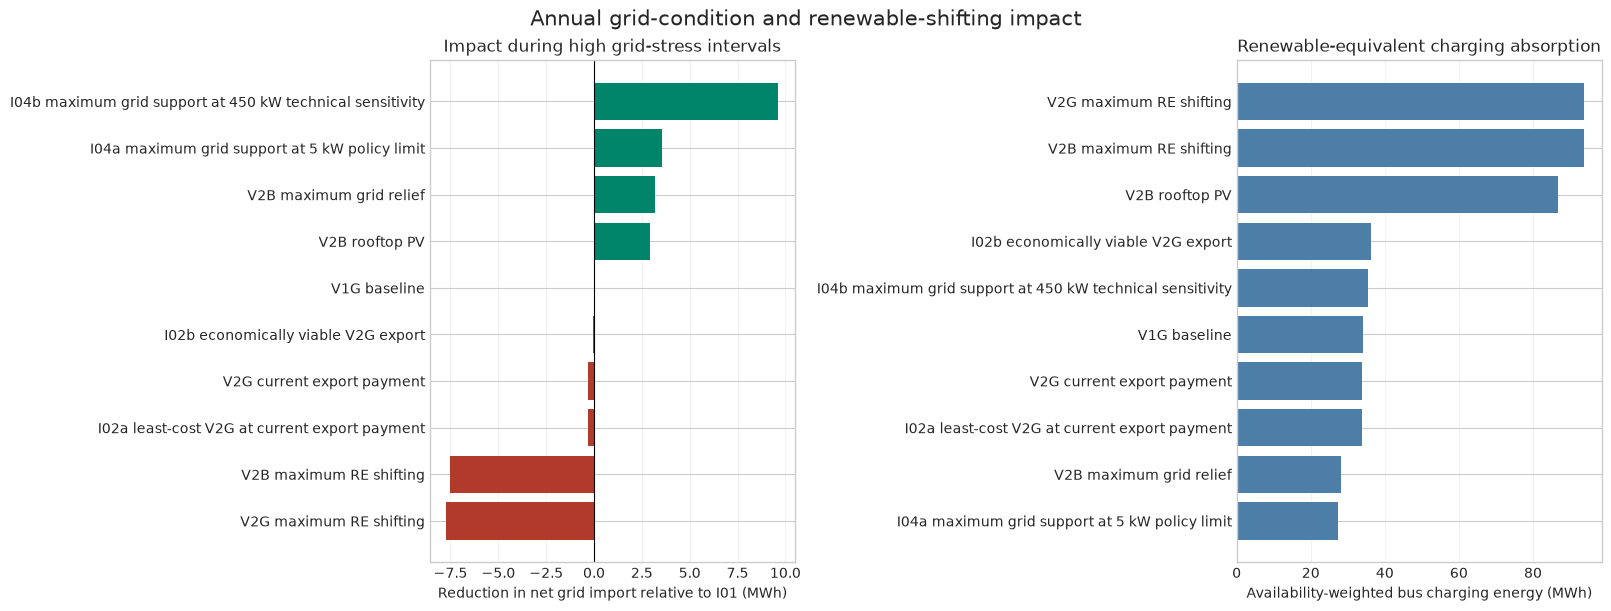

In [33]:
# Grid-service indicators are evaluated against the I01 electric charging reference.
impact = comparison.drop(index='Diesel benchmark', errors='ignore').copy()
impact = impact.loc[impact.index.intersection(dispatch_by_case)]

figure, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

grid_relief = impact['grid_support_during_stress_MWh'].fillna(0.0).sort_values()
grid_colors = np.where(grid_relief >= 0.0, '#00856a', '#b23a2b')
axes[0].barh(grid_relief.index, grid_relief.values, color=grid_colors)
axes[0].axvline(0.0, color='black', linewidth=0.8)
axes[0].set_title('Impact during high grid-stress intervals')
axes[0].set_xlabel('Reduction in net grid import relative to I01 (MWh)')

renewable_absorption = impact['renewable_absorbed_MWh'].fillna(0.0).sort_values()
axes[1].barh(renewable_absorption.index, renewable_absorption.values, color='#4d7ea8')
axes[1].set_title('Renewable-equivalent charging absorption')
axes[1].set_xlabel('Availability-weighted bus charging energy (MWh)')

for axis in axes:
    axis.grid(axis='x', alpha=0.25)
    axis.set_axisbelow(True)

figure.suptitle('Annual grid-condition and renewable-shifting impact', fontsize=15)
plt.show()


## 4. Cross-case comparison plots

Operational CO₂ uses the constant grid factor declared above, so the renewable-aware objective is not automatically a carbon result. Replace the constant with an approved time-varying grid-emissions series before using it as a carbon-aware case.

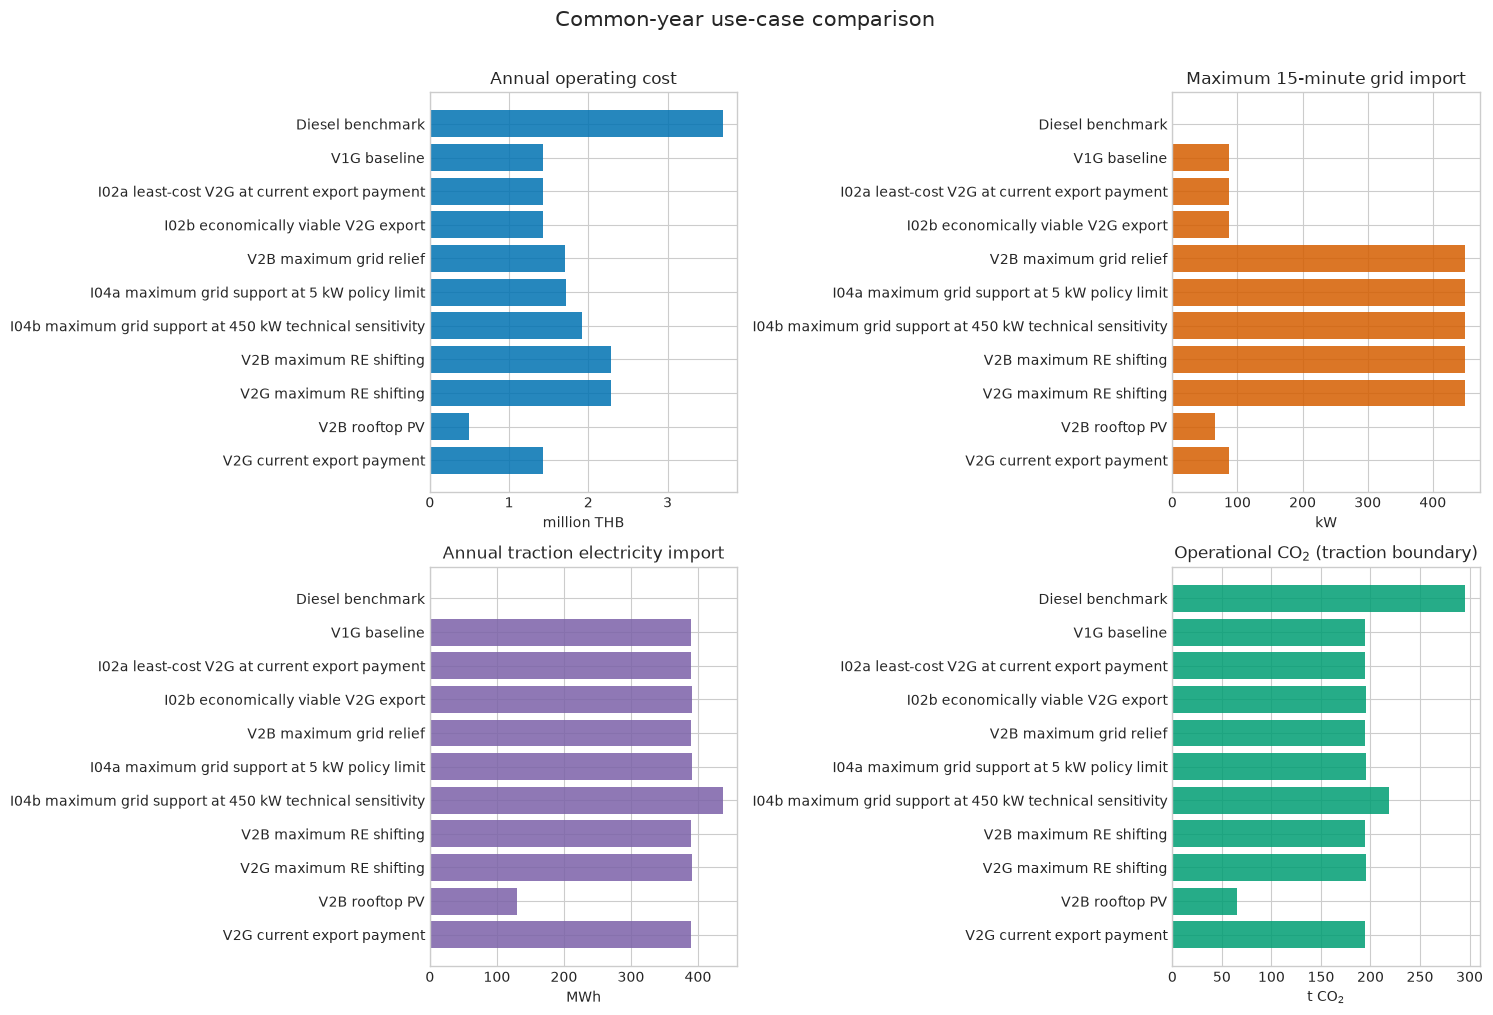

In [34]:
figure, axes = plt.subplots(2, 2, figsize=(15, 10))
plot_data = comparison.copy()
plot_data['total_cost_million_THB'] = plot_data['total_cost_THB'] / 1e6
plot_data['peak_grid_import_kW'] = plot_data['peak_grid_import_MW'] * 1000
plot_data['operational_CO2_t'] = plot_data['operational_CO2_kg'] / 1000
for axis, column, title, ylabel, color in [
    (axes[0, 0], 'total_cost_million_THB', 'Annual operating cost', 'million THB', COLORS['blue']),
    (axes[0, 1], 'peak_grid_import_kW', 'Maximum 15-minute grid import', 'kW', COLORS['orange']),
    (axes[1, 0], 'grid_import_MWh', 'Annual traction electricity import', 'MWh', COLORS['purple']),
    (axes[1, 1], 'operational_CO2_t', 'Operational CO$_2$ (traction boundary)', 't CO$_2$', COLORS['green']),
]:
    values = plot_data[column]
    axis.barh(values.index, values, color=color, alpha=0.85)
    axis.set_title(title)
    axis.set_xlabel(ylabel)
    axis.invert_yaxis()
figure.suptitle('Common-year use-case comparison', fontsize=15, y=1.01)
figure.tight_layout()
plt.show()

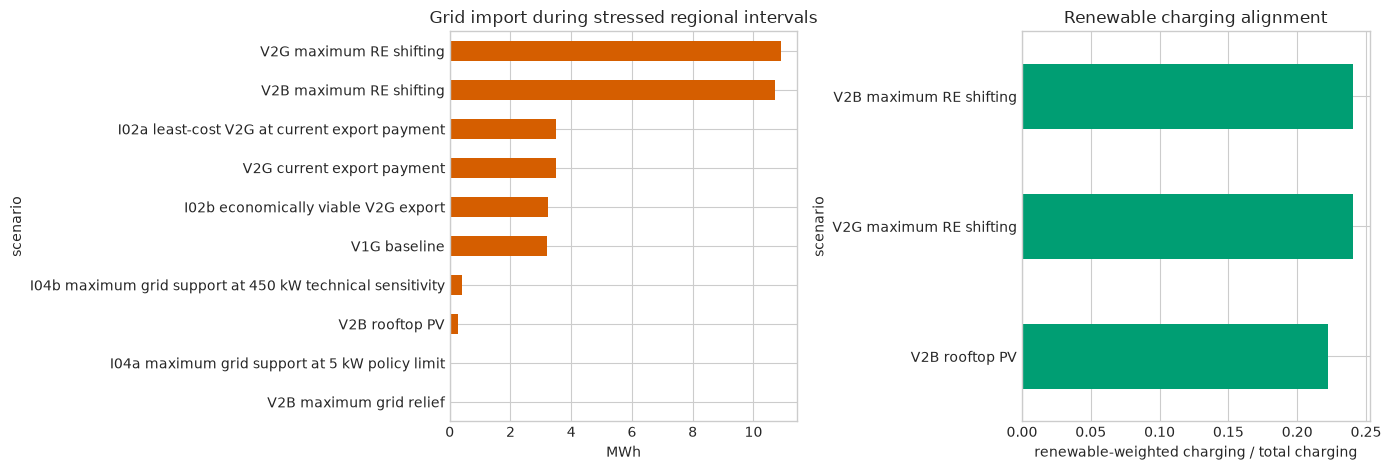

In [35]:
electric_only = comparison.drop(index='Diesel benchmark', errors='ignore')
figure, axes = plt.subplots(1, 2, figsize=(14, 4.8))
electric_only['grid_import_during_stress_MWh'].sort_values().plot.barh(ax=axes[0], color=COLORS['orange'])
axes[0].set_title('Grid import during stressed regional intervals')
axes[0].set_xlabel('MWh')
alignment = electric_only['renewable_alignment_score'].dropna().sort_values()
if not alignment.empty:
    alignment.plot.barh(ax=axes[1], color=COLORS['green'])
    axes[1].set_xlabel('renewable-weighted charging / total charging')
else:
    axes[1].text(0.5, 0.5, 'No renewable KPI in available outputs', ha='center', va='center')
axes[1].set_title('Renewable charging alignment')
figure.tight_layout()
plt.show()

## 5. Representative operation and duration curves

The week plot explains *how* the strategies differ. The load-duration plot uses all 35,136 intervals and therefore complements the annual peak KPI.

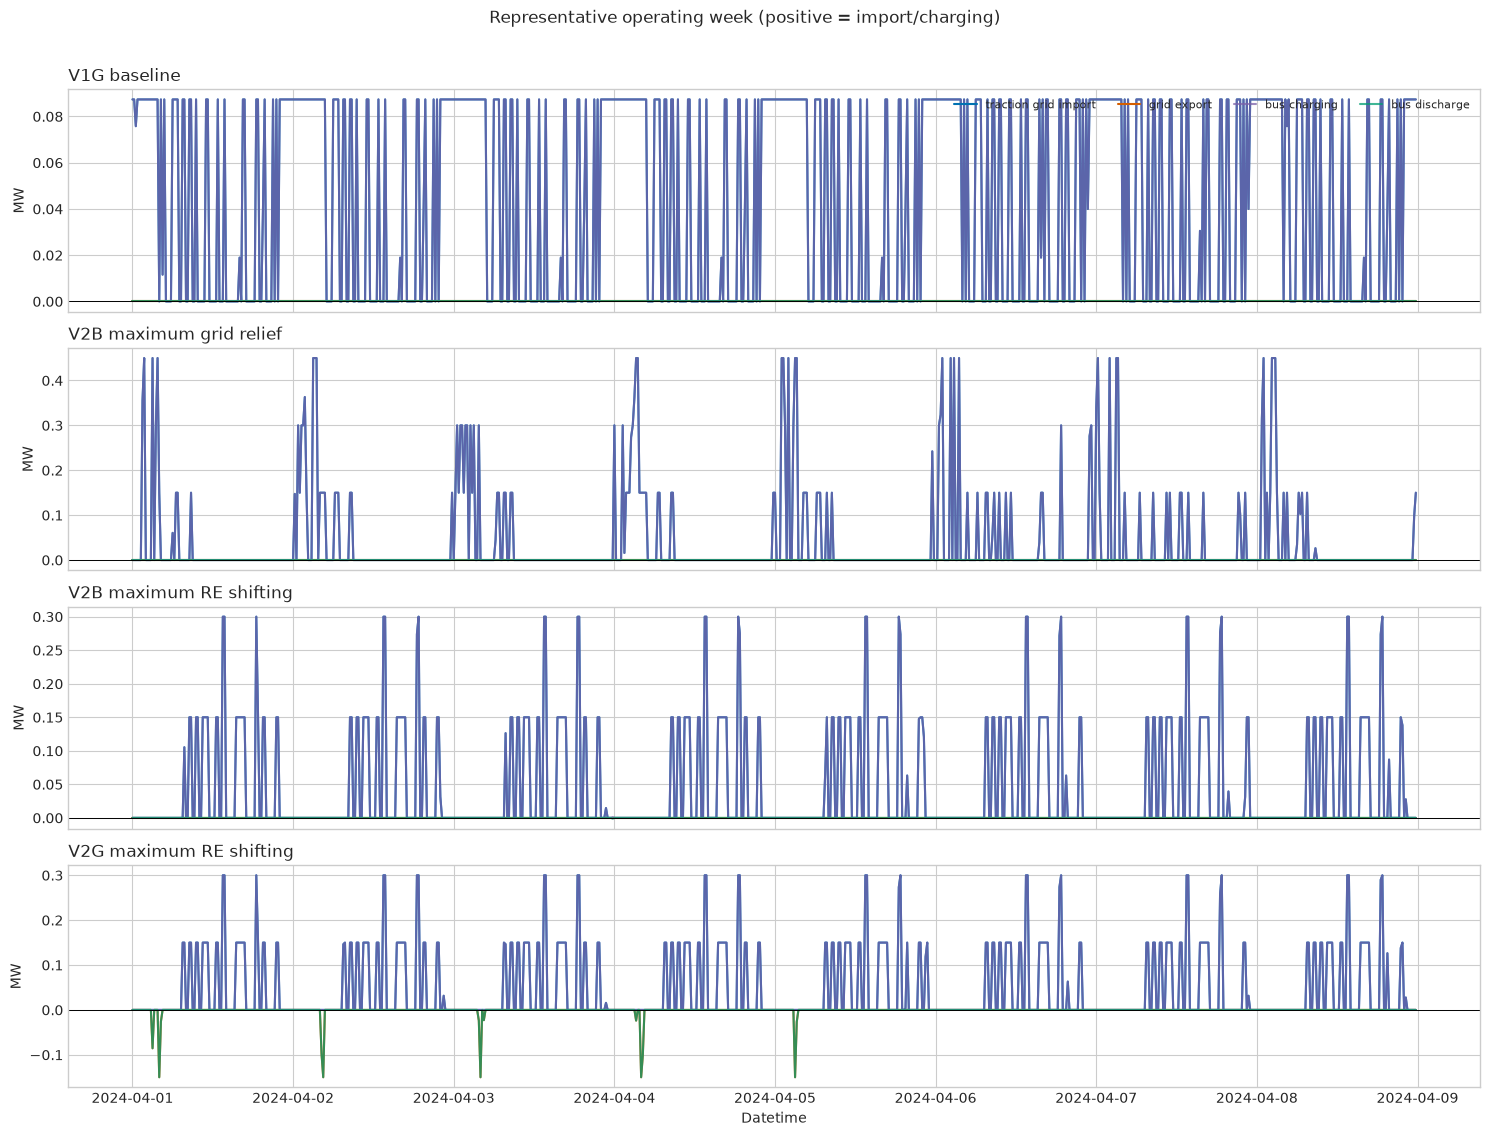

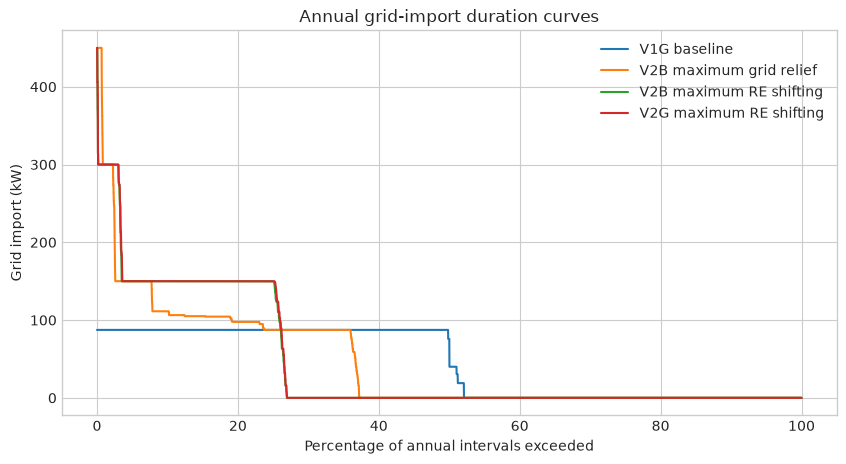

In [36]:
selected_labels = [label for label in ('V1G baseline', 'I02 least-cost V2G export', 'V2B maximum grid relief', 'V2G maximum grid support', 'V2B maximum RE shifting', 'V2G maximum RE shifting') if label in dispatch_by_case]
week_start = '2024-04-01'
week_end = '2024-04-08'
if selected_labels:
    figure, axes = plt.subplots(len(selected_labels), 1, figsize=(15, 2.8 * len(selected_labels)), sharex=True, squeeze=False)
    for axis, label in zip(axes[:, 0], selected_labels, strict=False):
        week = dispatch_by_case[label].loc[week_start:week_end]
        axis.plot(week.index, week['traction_grid_import_MW'], label='traction grid import', color=COLORS['blue'])
        axis.plot(week.index, -week['grid_export_MW'], label='grid export', color=COLORS['orange'])
        axis.plot(week.index, week['bus_charge_MWh'] / 0.25, label='bus charging', color=COLORS['purple'], alpha=0.75)
        axis.plot(week.index, -week['bus_discharge_MWh'] / 0.25, label='bus discharge', color=COLORS['green'], alpha=0.75)
        if week['pv_generation_MWh'].max() > 0:
            axis.fill_between(week.index, 0, week['pv_generation_MWh'] / 0.25, color='#F0C808', alpha=0.35, label='PV used')
        axis.axhline(0, color='black', linewidth=0.7)
        axis.set_ylabel('MW')
        axis.set_title(label, loc='left')
    axes[0, 0].legend(ncol=5, fontsize=8, loc='upper right')
    axes[-1, 0].set_xlabel('Datetime')
    figure.suptitle('Representative operating week (positive = import/charging)', y=1.01)
    figure.tight_layout()
    plt.show()

    figure, axis = plt.subplots(figsize=(10, 5))
    for label in selected_labels:
        values = np.sort(dispatch_by_case[label]['traction_grid_import_MW'].to_numpy())[::-1]
        axis.plot(np.linspace(0, 100, len(values)), values * 1000, label=label)
    axis.set(xlabel='Percentage of annual intervals exceeded', ylabel='Grid import (kW)', title='Annual grid-import duration curves')
    axis.legend()
    plt.show()

## 6. Rooftop-PV balance

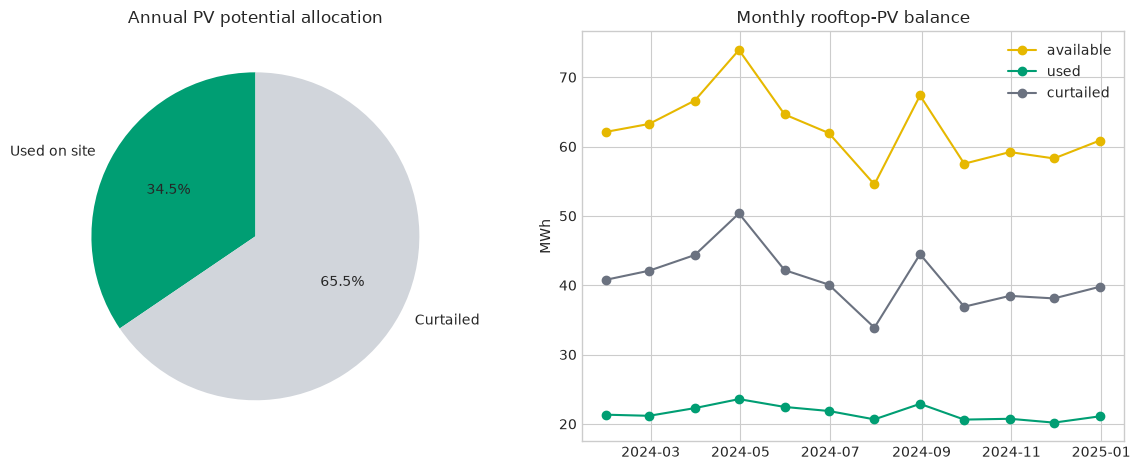

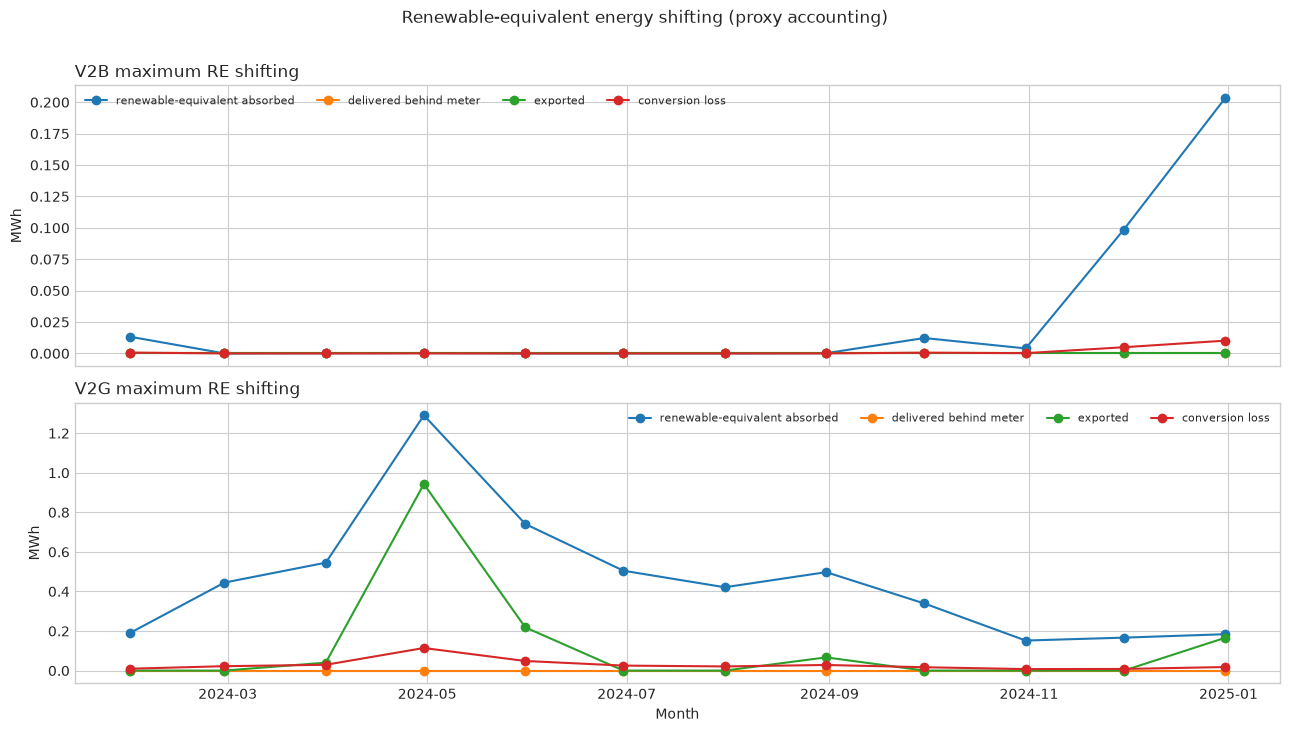

In [37]:
pv_label = 'V2B rooftop PV'
if pv_label in comparison.index:
    pv = comparison.loc[pv_label]
    pv_balance = pd.Series({'Used on site': pv['pv_used_MWh'], 'Curtailed': pv['pv_curtailment_MWh']})
    figure, axes = plt.subplots(1, 2, figsize=(12, 4.8))
    axes[0].pie(pv_balance, labels=pv_balance.index, autopct='%1.1f%%', colors=[COLORS['green'], '#D1D5DB'], startangle=90)
    axes[0].set_title('Annual PV potential allocation')
    monthly_pv = dispatch_by_case[pv_label].resample('ME')[['pv_available_generation_MWh', 'pv_generation_MWh', 'pv_curtailment_MWh']].sum()
    axes[1].plot(monthly_pv.index, monthly_pv['pv_available_generation_MWh'], marker='o', label='available', color='#E6B800')
    axes[1].plot(monthly_pv.index, monthly_pv['pv_generation_MWh'], marker='o', label='used', color=COLORS['green'])
    axes[1].plot(monthly_pv.index, monthly_pv['pv_curtailment_MWh'], marker='o', label='curtailed', color=COLORS['grey'])
    axes[1].set(title='Monthly rooftop-PV balance', ylabel='MWh')
    axes[1].legend()
    figure.tight_layout()
    plt.show()

renewable_labels = [label for label in ('V2B maximum RE shifting', 'V2G maximum RE shifting') if label in dispatch_by_case]
if renewable_labels:
    figure, axes = plt.subplots(len(renewable_labels), 1, figsize=(13, 3.6 * len(renewable_labels)), sharex=True, squeeze=False)
    for axis, label in zip(axes[:, 0], renewable_labels, strict=False):
        monthly = dispatch_by_case[label].resample('ME')[['renewable_equivalent_charge_MWh', 'renewable_equivalent_discharge_to_site_MWh', 'renewable_equivalent_grid_export_MWh', 'renewable_equivalent_conversion_loss_MWh']].sum()
        axis.plot(monthly.index, monthly['renewable_equivalent_charge_MWh'], marker='o', label='renewable-equivalent absorbed')
        axis.plot(monthly.index, monthly['renewable_equivalent_discharge_to_site_MWh'], marker='o', label='delivered behind meter')
        axis.plot(monthly.index, monthly['renewable_equivalent_grid_export_MWh'], marker='o', label='exported')
        axis.plot(monthly.index, monthly['renewable_equivalent_conversion_loss_MWh'], marker='o', label='conversion loss')
        axis.set_ylabel('MWh')
        axis.set_title(label, loc='left')
        axis.legend(ncol=4, fontsize=8)
    axes[-1, 0].set_xlabel('Month')
    figure.suptitle('Renewable-equivalent energy shifting (proxy accounting)', y=1.01)
    figure.tight_layout()
    plt.show()

## 7. Cartographic view of modeled bus services

The lines below are simplified geographic corridors assembled from documented termini and major corridor points. They support study communication and spatial orientation only. They must not be used for stop-level distance, scheduling, or navigation; replace the GeoJSON with validated GTFS/GPS shapes if these become available. Annual kilometres shown in the labels come from the simulation forecast—not from the map geometry.

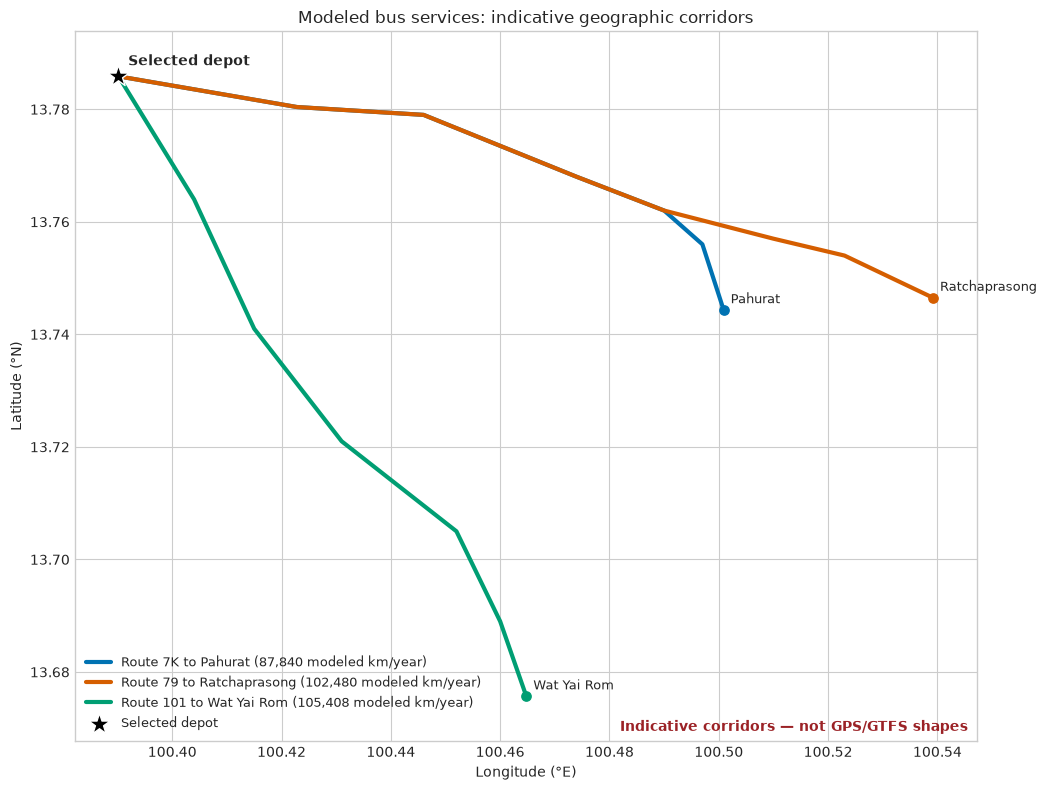

In [38]:
with ROUTE_PATH.open(encoding='utf-8') as stream:
    route_geojson = json.load(stream)
figure, axis = plt.subplots(figsize=(12, 8))
all_lon, all_lat = [], []
for feature in route_geojson['features']:
    coordinates = np.asarray(feature['geometry']['coordinates'])
    properties = feature['properties']
    bus_name = properties['model_bus']
    annual_km = route_totals.get(bus_name, np.nan)
    label = f"Route {properties['route_id']} to {properties['terminus']} ({annual_km:,.0f} modeled km/year)"
    axis.plot(coordinates[:, 0], coordinates[:, 1], linewidth=3, color=properties['color'], label=label)
    axis.scatter(coordinates[-1, 0], coordinates[-1, 1], s=45, color=properties['color'], zorder=4)
    axis.annotate(properties['terminus'], coordinates[-1], xytext=(5, 5), textcoords='offset points', fontsize=9)
    all_lon.extend(coordinates[:, 0])
    all_lat.extend(coordinates[:, 1])
depot_lon, depot_lat = 100.3901683, 13.7858496
axis.scatter(depot_lon, depot_lat, marker='*', s=260, color='black', edgecolor='white', linewidth=1, zorder=5, label='Selected depot')
axis.annotate('Selected depot', (depot_lon, depot_lat), xytext=(7, 8), textcoords='offset points', fontweight='bold')
axis.set_xlim(min(all_lon) - 0.008, max(all_lon) + 0.008)
axis.set_ylim(min(all_lat) - 0.008, max(all_lat) + 0.008)
axis.set_aspect(1 / np.cos(np.deg2rad(np.mean(all_lat))))
axis.set(xlabel='Longitude (°E)', ylabel='Latitude (°N)', title='Modeled bus services: indicative geographic corridors')
axis.legend(loc='lower left', fontsize=9)
axis.text(0.99, 0.01, 'Indicative corridors — not GPS/GTFS shapes', transform=axis.transAxes, ha='right', va='bottom', color='#9B2226', fontweight='bold')
figure.tight_layout()
plt.show()

### Interactive road basemap

This interactive figure is the cartographic companion to the static corridor plot above. It uses the OpenStreetMap road basemap when the notebook is viewed online. The coloured route lines remain indicative study corridors; they are not GPS traces or GTFS shapes.

In [39]:
road_map = go.Figure()
route_km_total = 0.0
for feature in route_geojson['features']:
    coordinates = np.asarray(feature['geometry']['coordinates'])
    properties = feature['properties']
    route_id = properties['route_id']
    terminus = properties['terminus']
    color = properties['color']
    annual_km = float(route_totals.get(properties['model_bus'], 0.0))
    route_km_total += annual_km

    # A pale casing keeps each corridor visible above the road basemap.
    road_map.add_trace(go.Scattermap(
        lon=coordinates[:, 0], lat=coordinates[:, 1], mode='lines',
        line={'width': 10, 'color': 'rgba(255, 255, 255, 0.90)'},
        hoverinfo='skip', showlegend=False,
    ))
    road_map.add_trace(
        go.Scattermap(
            lon=coordinates[:, 0],
            lat=coordinates[:, 1],
            mode='lines+markers',
            line={'width': 5, 'color': color},
            marker={'size': 5, 'color': color},
            name=f"Route {properties['route_id']} — {properties['terminus']}",
            hovertemplate=(
                f"Route {properties['route_id']}<br>Terminus: {properties['terminus']}"
                f'<br>Modeled distance: {annual_km:,.0f} km/year'
                '<br>Indicative service corridor<extra></extra>'
            ),
        )
    )

    # A route identifier and terminus pin make the service pattern legible.
    badge_index = max(1, int((len(coordinates) - 1) * 0.65))
    road_map.add_trace(go.Scattermap(
        lon=[coordinates[badge_index, 0]], lat=[coordinates[badge_index, 1]],
        mode='markers+text',
        marker={'size': 20, 'color': color},
        text=[route_id], textposition='middle center',
        textfont={'color': 'white', 'size': 10}, showlegend=False,
        hovertemplate=f'<b>Route {route_id}</b><br>Outbound to {terminus}<extra></extra>',
    ))
    road_map.add_trace(go.Scattermap(
        lon=[coordinates[-1, 0]], lat=[coordinates[-1, 1]],
        mode='markers+text',
        marker={'size': 13, 'color': color},
        text=[f'{route_id}: {terminus}'], textposition='top right',
        textfont={'color': color, 'size': 11}, showlegend=False,
        hovertemplate=f'<b>Route {route_id} terminus</b><br>{terminus}<extra></extra>',
    ))
# The depot beacon is deliberately drawn last, above all route origins.
road_map.add_trace(go.Scattermap(
    lon=[depot_lon], lat=[depot_lat], mode='markers',
    marker={'size': 38, 'color': '#F4A261'},
    showlegend=False, hoverinfo='skip',
))
road_map.add_trace(
    go.Scattermap(
        lon=[depot_lon],
        lat=[depot_lat],
        mode='markers+text',
        marker={'size': 18, 'color': '#111111'},
        text=['BUS DEPOT'],
        textposition='top right',
        textfont={'color': '#111111', 'size': 14},
        name='Selected depot',
        hovertemplate='<b>Selected depot</b><br>Origin of all modeled services<extra></extra>',
    )
)
road_map.update_layout(
    title={'text': 'Modeled bus-service network <sup>outbound indicative corridors</sup>', 'x': 0.01, 'xanchor': 'left'},
    map={'style': 'open-street-map', 'center': {'lon': 100.465, 'lat': 13.735}, 'zoom': 10.35},
    margin={'l': 0, 'r': 0, 't': 50, 'b': 0},
    legend={'orientation': 'h', 'y': 0.01, 'x': 0.01, 'xanchor': 'left', 'bgcolor': 'rgba(255, 255, 255, 0.85)'},
    annotations=[
        {
            'text': f'3 modeled services | {route_km_total:,.0f} vehicle-km/year',
            'xref': 'paper',
            'yref': 'paper',
            'x': 0.01,
            'y': 0.96,
            'xanchor': 'left',
            'yanchor': 'top',
            'showarrow': False,
            'bgcolor': 'rgba(255, 255, 255, 0.88)',
            'bordercolor': 'rgba(0, 0, 0, 0.18)',
            'borderwidth': 1,
        },
        {
            'text': 'Route lines are indicative corridors, not GPS/GTFS shapes. Map data © OpenStreetMap contributors.',
            'xref': 'paper',
            'yref': 'paper',
            'x': 0.99,
            'y': 0.01,
            'xanchor': 'right',
            'yanchor': 'bottom',
            'showarrow': False,
            'bgcolor': 'rgba(255, 255, 255, 0.80)',
        }
    ],
)
road_map.show()

## 8. Depot roof geometry, usable area, and PV potential

The left panel is a GIS-style plot in local metre coordinates calculated from the roof GeoJSON. It shows measured polygon areas, not a structural suitability survey. The right panel applies the documented 50%, 65%, and 80% usable-roof assumptions and 0.20 kWp/m² module density.

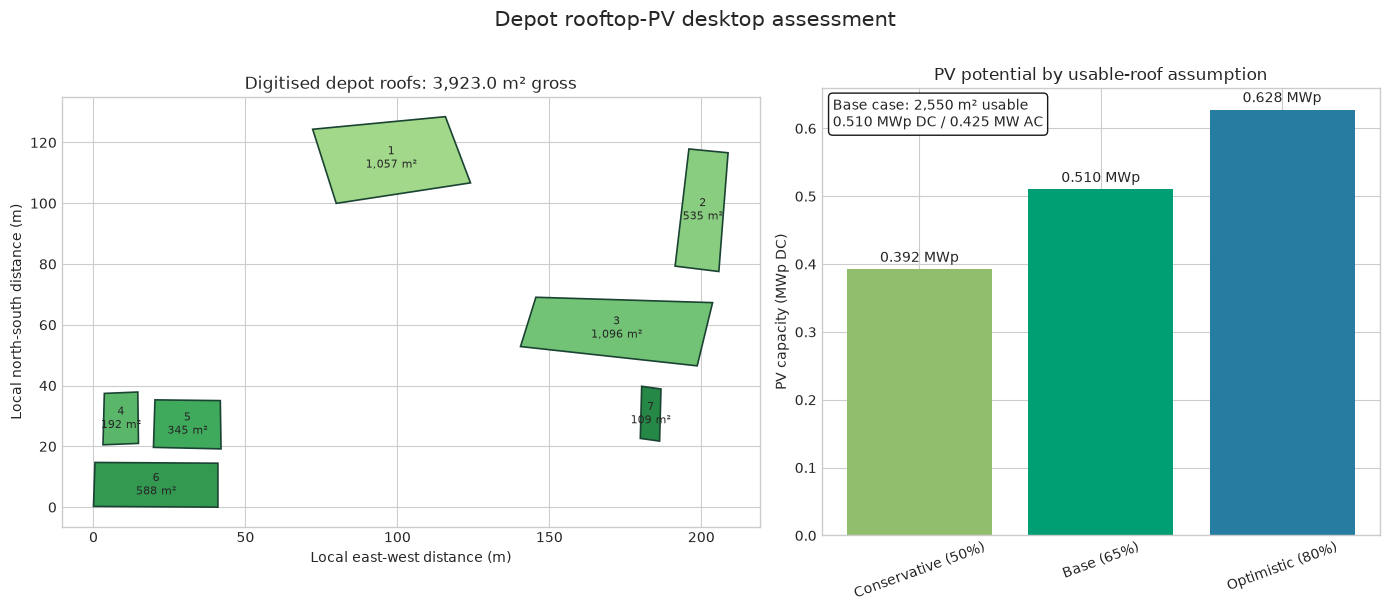

,usable_fraction,usable_area_m2,pv_capacity_mwp_dc,inverter_capacity_mw_ac
Conservative (50%),0.50,1961.50,0.392,0.327
Base (65%),0.65,2549.95,0.510,0.425
Optimistic (80%),0.80,3138.40,0.628,0.523


In [40]:
with ROOF_PATH.open(encoding='utf-8') as stream:
    roof_geojson = json.load(stream)
features = roof_geojson['features']
all_coordinates = np.vstack([np.asarray(feature['geometry']['coordinates'][0]) for feature in features])
origin_lon, origin_lat = all_coordinates[:, 0].min(), all_coordinates[:, 1].min()
metres_per_degree_lat = 111_320
metres_per_degree_lon = metres_per_degree_lat * np.cos(np.deg2rad(origin_lat))
gross_area_m2 = sum(float(feature['properties']['gross_area_m2']) for feature in features)
usable_fractions = pd.Series({'Conservative (50%)': 0.50, 'Base (65%)': 0.65, 'Optimistic (80%)': 0.80})
pv_capacity_mwp = gross_area_m2 * usable_fractions * 0.20 / 1000
figure, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1.25, 1]})
for index, feature in enumerate(features, start=1):
    lon_lat = np.asarray(feature['geometry']['coordinates'][0])
    x = (lon_lat[:, 0] - origin_lon) * metres_per_degree_lon
    y = (lon_lat[:, 1] - origin_lat) * metres_per_degree_lat
    area = float(feature['properties']['gross_area_m2'])
    axes[0].fill(x, y, color=plt.cm.YlGn(0.35 + 0.055 * index), edgecolor='#1B4332', linewidth=1.2)
    axes[0].text(x[:-1].mean(), y[:-1].mean(), f'{index}\n{area:,.0f} m²', ha='center', va='center', fontsize=8)
axes[0].set_aspect('equal')
axes[0].set(xlabel='Local east-west distance (m)', ylabel='Local north-south distance (m)', title=f'Digitised depot roofs: {gross_area_m2:,.1f} m² gross')
bars = axes[1].bar(pv_capacity_mwp.index, pv_capacity_mwp.values, color=['#90BE6D', COLORS['green'], '#277DA1'])
axes[1].bar_label(bars, labels=[f'{value:.3f} MWp' for value in pv_capacity_mwp], padding=3)
axes[1].set(ylabel='PV capacity (MWp DC)', title='PV potential by usable-roof assumption')
axes[1].tick_params(axis='x', rotation=20)
base_dc_mwp = float(pv_capacity_mwp['Base (65%)'])
base_usable_area_m2 = gross_area_m2 * float(usable_fractions['Base (65%)'])
axes[1].text(0.02, 0.98, f'Base case: {base_usable_area_m2:,.0f} m² usable\n{base_dc_mwp:.3f} MWp DC / {base_dc_mwp / 1.20:.3f} MW AC', transform=axes[1].transAxes, va='top', bbox={'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.9})
figure.suptitle('Depot rooftop-PV desktop assessment', fontsize=15, y=1.01)
figure.tight_layout()
plt.show()
roof_table = pd.DataFrame({'usable_fraction': usable_fractions, 'usable_area_m2': gross_area_m2 * usable_fractions, 'pv_capacity_mwp_dc': pv_capacity_mwp, 'inverter_capacity_mw_ac': pv_capacity_mwp / 1.20})
display(roof_table.round(3))

### Interactive satellite roof map

This map places the digitised roof polygons on satellite imagery for visual context. Hover over a roof to see its gross area and its indicative base-case PV capacity. It is a desktop screening figure: imagery dates can vary by tile and zoom, and neither the imagery nor the polygons establish structural suitability, ownership, shading, or a construction design.

In [41]:
roof_center = all_coordinates.mean(axis=0)
base_usable_fraction = 0.65
module_density_kwp_per_m2 = 0.20

satellite_roof_map = go.Figure()
for index, feature in enumerate(features, start=1):
    coordinates = np.asarray(feature['geometry']['coordinates'][0])
    properties = feature['properties']
    gross_roof_area_m2 = float(properties['gross_area_m2'])
    base_pv_kwp = gross_roof_area_m2 * base_usable_fraction * module_density_kwp_per_m2
    satellite_roof_map.add_trace(
        go.Scattermap(
            lon=coordinates[:, 0], lat=coordinates[:, 1], mode='lines', fill='toself',
            fillcolor='rgba(46, 204, 113, 0.34)',
            line={'color': '#0B5345', 'width': 2},
            name=f'Roof {index}',
            hovertemplate=(
                f'<b>Roof {index}</b><br>Gross area: {gross_roof_area_m2:,.1f} m²'
                f'<br>Base-case PV potential: {base_pv_kwp:,.1f} kWp DC'
                '<br>Usable-roof assumption: 65%<extra></extra>'
            ),
        )
    )

satellite_roof_map.add_trace(
    go.Scattermap(
        lon=[roof_center[0]], lat=[roof_center[1]], mode='markers', name='Depot',
        marker={'size': 11, 'color': '#C0392B'},
        hovertemplate='<b>Depot roof cluster</b><extra></extra>',
    )
)
satellite_roof_map.update_layout(
    title='Depot roofs and indicative PV potential',
    map={
        'style': 'white-bg',
        'center': {'lon': roof_center[0], 'lat': roof_center[1]},
        'zoom': 17.2,
        'layers': [{
            'sourcetype': 'raster',
            'source': ['https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}'],
            'below': 'traces',
        }],
    },
    margin={'l': 0, 'r': 0, 't': 45, 'b': 0},
    legend={'orientation': 'h', 'y': 0.01, 'x': 0.01},
    annotations=[{
        'text': ('Imagery sources: Esri, DigitalGlobe, GeoEye, i-cubed, USDA FSA, USGS, AEX, '
                 'Getmapping, Aerogrid, IGN, IGP, swisstopo, and the GIS User Community. '
                 'Visual reference only; imagery date not confirmed.'),
        'xref': 'paper', 'yref': 'paper', 'x': 0.01, 'y': 0.02,
        'xanchor': 'left', 'yanchor': 'bottom', 'showarrow': False,
        'font': {'size': 9, 'color': '#1F2937'},
        'bgcolor': 'rgba(255, 255, 255, 0.82)',
    }],
)
satellite_roof_map.show()

## 9. Optional strategy sensitivities

The maximum grid-support and renewable-shifting configurations compare no export, the 5 kW policy sensitivity, and the 450 kW charger-based technical limit. The tariff cases retain the separate export-payment increments. Set `RUN_SENSITIVITY_CASES = True` and run the next cell to calculate missing outputs. Renewable quantities are availability-weighted technical proxies, not measured national curtailment.

/tmp/ipykernel_1690424/1586123130.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dispatch['traction_grid_import_MWh'] = (dispatch['grid_import_MWh'] - legacy_building_demand).clip(lower=0.0)
/tmp/ipykernel_1690424/1586123130.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dispatch['traction_grid_import_MW'] = dispatch['traction_grid_import_MWh'] / 0.25
/tmp/ipykernel_1690424/1586123130.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

Missing Export +2.0 THB/kWh: /root/FLEXIMOD/data/output/building_use_case_analysis/tariff_plus_2000
Missing Export +2.5 THB/kWh: /root/FLEXIMOD/data/output/building_use_case_analysis/tariff_plus_2500
Missing Export +3.0 THB/kWh: /root/FLEXIMOD/data/output/building_use_case_analysis/tariff_plus_3000
Missing Export +3.5 THB/kWh: /root/FLEXIMOD/data/output/building_use_case_analysis/tariff_plus_3500
Missing Export +4.0 THB/kWh: /root/FLEXIMOD/data/output/building_use_case_analysis/tariff_plus_4000
Missing Export +4.5 THB/kWh: /root/FLEXIMOD/data/output/building_use_case_analysis/tariff_plus_4500
Missing Export +5.0 THB/kWh: /root/FLEXIMOD/data/output/building_use_case_analysis/tariff_plus_5000


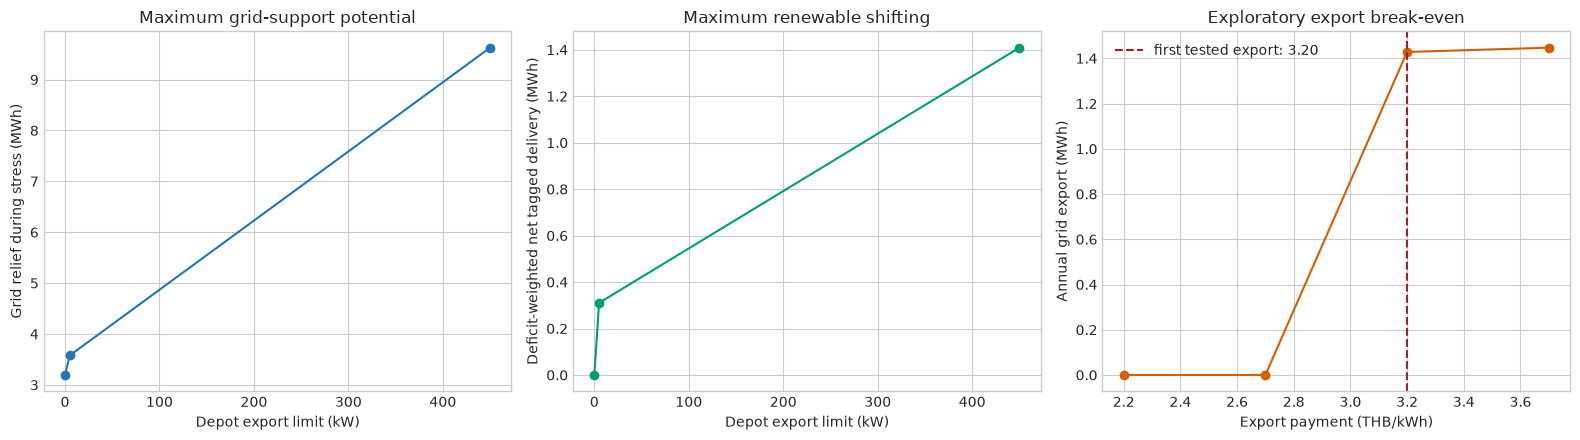

In [42]:
def sensitivity_frame(cases: dict, parameter: str) -> pd.DataFrame:
    rows = []
    for label, spec in cases.items():
        run_case(label, spec, RUN_SENSITIVITY_CASES)
        loaded = load_result(label, spec)
        if loaded is None:
            continue
        row, dispatch = loaded
        if 'V1G baseline' in dispatch_by_case:
            baseline = dispatch_by_case['V1G baseline']
            common_index = baseline.index.intersection(dispatch.index)
            relief = baseline.loc[common_index, 'net_grid_import_MWh'] - dispatch.loc[common_index, 'net_grid_import_MWh']
            threshold = float(dispatch.loc[common_index, 'grid_stress_threshold'].iloc[0])
            stressed = dispatch.loc[common_index, 'grid_congestion_weight'] >= threshold
            row['grid_support_during_stress_MWh'] = float(relief.loc[stressed].sum())
        row[parameter] = spec[parameter]
        rows.append(row)
    return pd.DataFrame(rows).sort_values(parameter) if rows else pd.DataFrame()

grid_sensitivity = sensitivity_frame(GRID_SUPPORT_CASES, 'export_limit_kw')
renewable_sensitivity = sensitivity_frame(RENEWABLE_CASES, 'export_limit_kw')
tariff_sensitivity = sensitivity_frame(TARIFF_CASES, 'increment_thb_per_kwh')
figure, axes = plt.subplots(1, 3, figsize=(16, 4.5))
if not grid_sensitivity.empty:
    axes[0].plot(grid_sensitivity['export_limit_kw'], grid_sensitivity['grid_support_during_stress_MWh'], marker='o')
    axes[0].set(xlabel='Depot export limit (kW)', ylabel='Grid relief during stress (MWh)', title='Maximum grid-support potential')
else:
    axes[0].text(0.5, 0.5, 'Sensitivity outputs not run', ha='center')
if not renewable_sensitivity.empty:
    axes[1].plot(renewable_sensitivity['export_limit_kw'], renewable_sensitivity['renewable_deficit_support_MWh'], marker='o', color=COLORS['green'])
    axes[1].set(xlabel='Depot export limit (kW)', ylabel='Deficit-weighted net tagged delivery (MWh)', title='Maximum renewable shifting')
else:
    axes[1].text(0.5, 0.5, 'Sensitivity outputs not run', ha='center')
if not tariff_sensitivity.empty:
    axes[2].plot(tariff_sensitivity['increment_thb_per_kwh'] + 2.20, tariff_sensitivity['grid_export_MWh'], marker='o', color=COLORS['orange'])
    axes[2].set(xlabel='Export payment (THB/kWh)', ylabel='Annual grid export (MWh)', title='Exploratory export break-even')
    exported = tariff_sensitivity.loc[tariff_sensitivity['grid_export_MWh'] > 1e-6]
    if not exported.empty:
        break_even = 2.20 + float(exported.iloc[0]['increment_thb_per_kwh'])
        axes[2].axvline(break_even, color='#9B2226', linestyle='--', label=f'first tested export: {break_even:.2f}')
        axes[2].legend()
else:
    axes[2].text(0.5, 0.5, 'Tariff sweep outputs not run', ha='center')
figure.tight_layout()
plt.show()

## 10. Interpretation checklist

1. Confirm all compared cases cover identical dates, route kilometres, fleet rows, and charger rows.
2. Report energy charges and monthly demand charges separately.
3. Use V1G as the electric operational reference and diesel as the drivetrain benchmark.
4. Keep grid-support, renewable-aware, and cost objectives distinct; a renewable proxy is not an emissions factor.
5. State clearly that the route corridors are indicative and that rooftop capacity requires site and structural surveys.
6. Keep operational costs and emissions separate from investment, lifecycle emissions, maintenance, and any later financial assessment.